<p align="center">
  <a href="https://imc.uc.cl" target="_blank">
    <img src="attachment:image.png" alt="IMC" width="220">
  </a>
</p>

# IMT 2200 - Introducción a Ciencia de Datos
**Pontificia Universidad Católica de Chile**<br>
**Instituto de Ingeniería Matemática y Computacional**<br>
**Profesor:** Rodrigo A. Carrasco <br>
---


## Tarea 04 – Aprendizaje automático

- **Fecha de Entrega:** 13 de noviembre de 2025, a las 23:59.
- **Fecha de publicación**: 30 de octubre de 2025.
- **Formato de entrega:** Notebook ejecutado y comentado (`.ipynb`) en el módulo de Tarea 04 habilitado en Canvas.

## Instrucciones

- Esta Tarea debe desarrollarse de manera totalmente *individual*, de acuerdo a lo establecido en la sección de Integridad Académica en el programa del curso.
- La Tarea debe ser desarrollada en lenguaje de programación Python y la entrega en formato Jupyter Notebook.
- El desarrollo del Notebook debe ser claro y ordenado, incluyendo anotaciones (markdown) y comentarios que permitan seguir fácilmente el código y los pasos implementados a los correctores, y siguiendo buenas prácticas de programación. La presentación y claridad del notebook y código forman parte de la evaluación de la tarea.
- Notebook **autocontenible** que:
   - Ejecute sin errores todas las celdas.
  - Contenga tanto el código como los comentarios y explicaciones necesarias.
  - Incluya visualizaciones claras y correctamente etiquetadas.
- No se aceptarán notebooks con celdas rotas o que dependan de rutas externas no indicadas en la tara.

- Deben hacer sus consultas y comentarios sobre la Tarea a traves del canal de Tareas en eo del curso en Canvas.os.
cteriza.

## 1. Objetivos

- Aplicar los conceptos iniciales de manejo de datos y análisis exploratorio vistos en clases.
- Practicar la lectura, limpieza y manipulación de datos en Python.
- Desarrollar habilidades para visualizar y describir patrones y tendencias en conjuntos de datos reales.
- Fomentar la capacidad de comunicar resultados de forma clara y fundamentada.

### 1.1 Objetivo educacional

Esta Tarea tiene como objetivo que los estudiantes desarrollen la capacidad de manejar algunas de las librerías centrales para el desarrollo de Ciencia de Datos, con foco en la lectura y exploración de datos. 

### 1.2 Pregunta de ciencia de datos

Esta tarea tendrá como objetivo crear un predictor que determine el éxito o fracaso de una expedición a distintas montañas del Himalayas según datos del montañista y de la expedición. Vamos a responder a la pregunta de qué tan bien pueden atributos como año, estación, montaña, edad del montañista, entre otros, predecir el éxito o fracaso de una expedición.

### 1.3 Recomendaciones
- Utiliza las librerías sugeridas en el notebook o justifica brevemente si incorporas otras.
- Revisa que todas las celdas se ejecuten en orden, desde el inicio, sin errores.
- Comenta tu código para explicar qué hace cada sección relevante.
- Asegúrate de que las visualizaciones sean fáciles de interpretar y tengan títulos y etiquetas adecuados.

## 2. Datos

[The Himalayan Database](https://www.himalayandatabase.com/) consiste en una colección de registros de expediciones en la cordillera del Himalaya. Esta contiene información detallada de las cimas más altas del mundo, junto con miles de expediciones realizadas desde 1905 hasta 2024 e información de cada uno de los/las montañistas que han participado en ellas. (El dataset que utilizaremos fue extraído desde: https://mavenanalytics.io/data-playground/himalayan-expeditions)

Descargue el archivo `Himalayan+Expeditions.zip` disponible en el repositorio del curso. Como puede ver, esta información está separada en varios archivos `.csv`. Deberá utilizar las herramientas aprendidas durante el curso para juntar esta información, procesarla y crear un predictor que determine el éxito de una subida.

**Recomendación**: Puede revisar el archivo `himalayan_data_dictionary.csv` para saber el significado de cada una de las columnas de la base de datos.

### 2.1 Librerías

Para esta tarea puede utilizar cualquiera de las librerías previamente utilizadas en el curso. Puede agregar otras si lo estima conveniente para el desarrollo de la Tarea.

In [266]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
# ...agreuge otras librerías si lo considera relevante

## 3. Carga y limpieza (1 punto)

### 3.1 DataFrame unificado (0.2 pts)

Inspeccione los atributos de cada dataset y extraiga la siguiente información de ellos:

1. Información de las montañas:
    * ID de la cima (`peakid`)
    * Nombre común de la montaña (`pkname`)
    * Altura (m) (`heightm`)
    * Cantidad de expediciones exitosas (`success_exp`)
    * Cantidad de expediciones fallidas (`failed_exp`)

2. Información de las expediciones:
    * ID de la expedición (`expid`)
    * Año (`year`)
    * Estación del año (`season`)

3. Información de los montañistas:
    * ID del miembro (`memid`)
    * Sexo (`sex`)
    * Año de nacimiento (`yob`)
    * Nacionalidad (`citizen`)
    * Completó la expedición exitosamente (`msuccess`)

Genere un único DataFrame con todos estos atributos, donde cada fila represente el ascenso de un/a montañista en una expedición. (Ojo que esto no necesariamente significa que cada fila será una persona diferente: si una persona escaló dos cumbres distintas en dos expediciones, esta debería aparecer en su DataFrame como dos filas separadas.)


In [267]:
mont_crudo=pd.read_csv('Himalayan+Expeditions/peaks.csv', usecols= ['peakid', 'pkname', 'heightm'])
pwe_crudo=pd.read_csv('Himalayan+Expeditions/peaks_with_exp.csv', usecols=['peakid', 'success_exp', 'failed_exp'] )
exped_crudo=pd.read_csv('Himalayan+Expeditions/exped.csv', usecols=['expid', 'peakid', 'year', 'season'])
miem_crudo=pd.read_csv('Himalayan+Expeditions/members.csv', usecols=['membid', 'expid', 'peakid', 'sex', 'yob', 'citizen', 'msuccess'])

In [268]:
print(len(exped_crudo[exped_crudo['expid'].duplicated()]))

4


In [269]:
miem_y_exp= miem_crudo.merge(exped_crudo[['expid', 'year', 'season']], how='left', on='expid')
miem_y_exp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 89089 entries, 0 to 89088
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   expid     89089 non-null  object 
 1   membid    89089 non-null  int64  
 2   peakid    89089 non-null  object 
 3   sex       89089 non-null  object 
 4   yob       83665 non-null  float64
 5   citizen   89082 non-null  object 
 6   msuccess  89089 non-null  bool   
 7   year      89089 non-null  int64  
 8   season    89089 non-null  object 
dtypes: bool(1), float64(1), int64(2), object(5)
memory usage: 5.5+ MB


In [270]:
mont_y_pwe= mont_crudo.merge(pwe_crudo, how='left', on='peakid')
mont_y_pwe.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 480 entries, 0 to 479
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   peakid       480 non-null    object
 1   pkname       480 non-null    object
 2   heightm      480 non-null    int64 
 3   failed_exp   480 non-null    int64 
 4   success_exp  480 non-null    int64 
dtypes: int64(3), object(2)
memory usage: 18.9+ KB


In [271]:
df=miem_y_exp.merge(mont_y_pwe, how='left', on='peakid')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 89089 entries, 0 to 89088
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   expid        89089 non-null  object 
 1   membid       89089 non-null  int64  
 2   peakid       89089 non-null  object 
 3   sex          89089 non-null  object 
 4   yob          83665 non-null  float64
 5   citizen      89082 non-null  object 
 6   msuccess     89089 non-null  bool   
 7   year         89089 non-null  int64  
 8   season       89089 non-null  object 
 9   pkname       89089 non-null  object 
 10  heightm      89089 non-null  int64  
 11  failed_exp   89089 non-null  int64  
 12  success_exp  89089 non-null  int64  
dtypes: bool(1), float64(1), int64(5), object(6)
memory usage: 8.2+ MB


### 3.2 Limpieza y transformación (0.2 pts)

Inspeccione y procese su DataFrame para generar uno nuevo llamado `clean_df`. En esta sección usted debe decidir si es necesario:

* Limpiar valores nulos, duplicados o inválidos.
* Imputar valores.
* Transformar tipos de columnas.

Justifique su procesamiento.

Proceso:

-Con los ides ('expid', 'peakid' y 'peakid') se confirma que no haya elementos nulos y que no haya miembros repetidos por expedición.

-yob: Una buena parte de las personas no tiene registrada su edad de nacimiento pero eliminarlos del Data Frame sería perder una buena parte de esta, un 6% aproximadamente, así que en los procesos en los que esta informacion sea necesaria, no vamos a conciderar a estos montañistas, así que se crearán dos data frames, uno que los contenga y otro que no. 
clean_df no va a tener a estas personas.

Como los que no tiene ciudadanía son muy pocos serán sacados del dataframe tambien aquellos que tengan doble ciudadanía ya que conforman un 0,5% de la población.

Los demás datos están limpios.


In [272]:
print(len(df[df['expid'].isnull()==True]))
print(len(df[df['membid'].isnull()==True]))
print(len(df[df['peakid'].isnull()==True]))
df_id=pd.DataFrame()
df_id['ids']=f'{df['expid']}{df['membid']}'
print(len(df_id.duplicated()==True))

0
0
0
0


In [273]:
print(f'Nan "yob": {len(df[df['yob'].isnull()])} ; {round(len(df[df['yob'].isnull()])*100/len(df), 1)}%')

Nan "yob": 5424 ; 6.1%


In [274]:
print(df['sex'].unique())
print(len(df[df['sex']=='X']))
df=df[df['sex']!='X']


['M' 'F' 'X']
1


In [275]:
print(len(df[df['citizen'].isnull()==True]))
df=df[df['citizen'].isnull()==False]
print(f'Nan citizen :{len(df[df['citizen'].str.contains('/')])} ; {round(len(df[df['citizen'].str.contains('/')])*100/len(df), 1)}%')
df=df[df['citizen'].str.contains('/')==False]



7
Nan citizen :471 ; 0.5%


In [276]:
print(df['msuccess'].unique())
print(len(df[df['msuccess'].isnull()]))
print(len(df[df['year'].isnull()]))
print(df['season'].unique())
print(len(df[df['season'].isnull()]))
print(len(df[df['pkname'].isnull()]))
print(len(df[df['heightm'].isnull()]))
print(len(df[df['failed_exp'].isnull()]))
print(len(df[df['success_exp'].isnull()]))


[False  True]
0
0
['Spring' 'Autumn' 'Winter' 'Summer']
0
0
0
0
0


In [277]:
clean_df=df[df['yob'].isnull()==False].copy()
clean_df['yob']=clean_df['yob']
print(f'filas df completo: {len(df)}\nfilas df sin Nan en "yob": {len(clean_df)}')

filas df completo: 88610
filas df sin Nan en "yob": 83202


### 3.2 Creación de nuevas columnas (0.6 pts)

Vamos a crear un par de columnas nuevas que nos ayudarán a hacer una análisis exploratorio del dataset.
Utilizando las columnas actuales, genere y agregue las siguientes columnas a su DataFrame:

* `age`: Edad del montañista a la fecha de la expedición.
* `peak_success_p`: Porcentaje de expediciones exitosas de la cima respectiva.

De ser necesario, aplique procesos de limpieza y transformación a estas columnas también (asegúrese de que todos los valores sean coherentes).

In [278]:
clean_df['age']=clean_df['year']-clean_df['yob']
clean_df['age'].describe()


count    83202.000000
mean        38.248407
std         11.000464
min        -78.000000
25%         30.000000
50%         37.000000
75%         45.000000
max        156.000000
Name: age, dtype: float64

Notamos que hay datos que se salen del rango realista, así que le pregunté a gemini lo siguente:

"minimum age to climb the Himalayan" 

Me respondió que el minimo legal en Nepal es 16 y en China es 18

"and the oldest person that has tried to climb a part of the Himalayan?"

Me respondió que la persona con mayor edad que a podido llegar al everest tenia 80 años y la que a llegado a alguna montaña alta del Himalayan tenía 86, así que voy a dejar un límite superior de 90 años.

In [279]:
condicion=(clean_df['age']>=16) & (clean_df['age']<=90) 
clean_df=clean_df[condicion]
clean_df['age'].describe()

count    83113.000000
mean        38.261896
std         10.568971
min         16.000000
25%         30.000000
50%         37.000000
75%         45.000000
max         86.000000
Name: age, dtype: float64

In [280]:

clean_df['peak_success_p']=clean_df['success_exp']*100/(clean_df['success_exp']+clean_df['failed_exp'])
clean_df['peak_success_p'].describe()


count    83113.000000
mean        58.124888
std         14.427651
min          0.000000
25%         50.000000
50%         63.355408
75%         63.698338
max        100.000000
Name: peak_success_p, dtype: float64

El enuncuado me hace paensar que se espera que se use la información entregada directamente del domucento peaks_with_exp.csv, pero ésta información puede que no se corresponda con las cantidades de gente que se tienen en el dataframe limpio, ya que se descartó a las personas que no tenian el año de nacimiento registrado.

## 4. EDA (2.5 puntos)

Con el dataset obtenido, responda las siguientes preguntas. Para cada una de ellas, realice al menos un gráfico que permita visualizar el comportamiento de su dataset.

a. **(0.5 pts)** ¿Cuántos ascensos exitosos y fallidos hay en su dataset? ¿A qué porcentaje del total corresponde cada categoría?

b. **(0.5 pts)** ¿Cómo se distribuyen las edades de los/las montañistas en la base de datos?

c. **(0.5 pts)** ¿Cómo se distribuye la cantidad de ascensos según estación del año? ¿Cuál es el porcentaje de éxito por estación? Muestre la cantidad de filas de ascensos exitosas y fallidas para cada estación.

d. **(0.5 pts)** ¿Cómo cambia la cantidad de ascensos en el tiempo? Muestre la cantidad de ascensos exitosos y fallidos por año.

e. **(0.5 pts)** ¿Existe una correlación entre el porcentaje de éxito de ascenso y la altura de una cumbre? Haga un scatterplot para todas las cumbres que hayan sido escaladas por al menos 10 expediciones en total (tanto fallidas como exitosas).

a) En esta pregunta se cuentan solamente a los miembros que estén en el data frame

In [281]:
ascensos=df['msuccess'].value_counts()
porcentajes=round(ascensos*100/(ascensos.sum()), 1)
print(ascensos)
print(porcentajes)




msuccess
False    51841
True     36769
Name: count, dtype: int64
msuccess
False    58.5
True     41.5
Name: count, dtype: float64


b)

[(10.0, 90.0)]

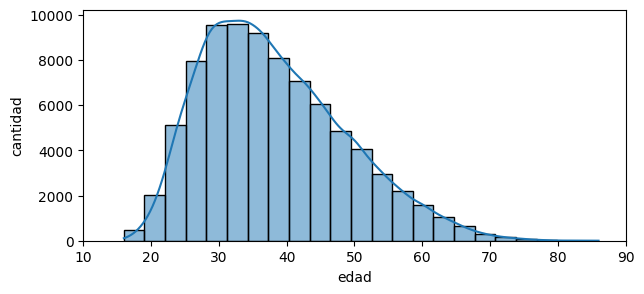

In [282]:
fig, ax = plt.subplots(1, 1, figsize=(7,3))
ax = sns.histplot(data=clean_df, x='age', bins=23, kde=True)
ax.set_xlabel('edad')
ax.set_ylabel('cantidad')
ax.set(xlim=(10, 90))

c)

In [290]:
estaciones=pd.DataFrame(df.groupby(['season','msuccess']).size())
estaciones.head()

0
season msuccess       
Autumn False     25398
       True      16410
Spring False     24185
       True      19600
Summer False       552

<Axes: xlabel='season', ylabel='msuccess'>

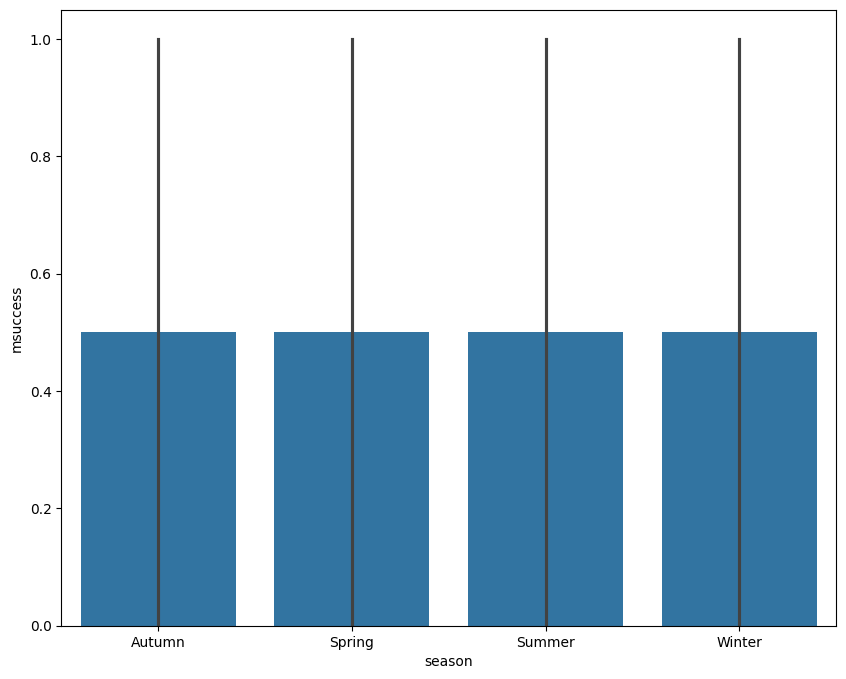

In [292]:
plt.figure(figsize=(10,8))

sns.barplot(data=estaciones,
            x='season',
            y='msuccess')

Respuestas:

## 5. Predictor (2.5 puntos)

Ahora veremos si la información que tenemos nos permite predecir el éxito de un ascenso por alguna persona en particular. Primero, defina su **X** (matriz de atributos) e **y** (etiqueta a predecir) de la siguiente manera:

* **X**: `age`, `sex`, `citizen`, `season`, `heightm`, `year`, `success_exp`, `failed_exp`
* **y**: `msuccess`

Luego, realice los pasos a continuación:

**5.1 Codificación y normalización (1 pto)**
* Codifique todas las columnas categóricas, de manera que su matriz **X** solo tenga valores numéricos.
* Divida sus datos en sets de entrenamiento y testeo. Use una división de 70-30.
* Normalice sus matrices de atributos. Justifique su método de normalización.

**5.2 Creación y entrenamiento de modelos (1 pto)**
* Cree y entrene los siguientes modelos:
    * Un clasificador KNN
    * Un árbol de decisión
    * Un clasificador de regresión logística
    * Un clasificador random forest **(Opcional)**

    Explique qué hiperparámetros utilizó para la creación de cada uno de ellos y qué valores le asignó.

* Finalmente, evalúe todos sus modelos con el set de testeo. Para cada uno, muestre
    * Accuracy
    * Precisión
    * Recall
    * Matriz de confusión

**5.3 Análisis de resultados (0.5 pts)**

Interprete, analice y comente sus resultados. 
* ¿Qué tendencias puede observar? ¿Se diferencian de alguna forma las predicciones entre un modelo y otro? 
* ¿Fue posible construir un predictor efectivo? Justique.



In [ ]:
# respuestas

Respuestas: